# 5 · Problems with Markowitz: Instability and Error Maximization

*Module 2 — Portfolio Construction*

The mathematically optimal portfolio is beautiful in theory. Re-estimate it next month and it can look nothing like it did before. This notebook shows why, precisely — and sets up every "fix" the rest of this module explores.

## 1. Motivation

You build the mean-variance optimal portfolio using five years of historical data. Next month, you add one more month of data and re-run the exact same optimization. The "optimal" weights are unrecognizable — a position that was +40% is now -15%. Nothing structural has changed about the companies involved. Yet the optimizer swung wildly. Portfolio managers have a name for this: Richard Michaud (1989) called mean-variance optimization an **"error maximizer."** This notebook shows exactly why that happens, with a controlled experiment where we — unlike in real life — actually know the true parameters, so we can watch estimation error get amplified in real time.

## 2. Intuition

Give an optimizer two assets that are highly correlated, and it will look for the tiniest edge between them — the smallest apparent difference in expected return or volatility — and bet enormous amounts on it, going long the "better" one and short the "worse" one. This looks, to the optimizer, almost like free money: if two things move together almost perfectly, a small edge between them seems nearly risk-free to exploit at large scale. But if the "edge" it found is not real — if it is just sampling noise in a few years of historical data — the optimizer has not found an arbitrage. It has built an enormous, confident bet on pure noise.

This is the core failure mode of mean-variance optimization: it cannot distinguish genuine signal from estimation error, and it actively seeks out and amplifies whatever noise happens to look most exploitable in the sample it was given. The more similar (correlated) your assets are, and the shorter your history, the worse this gets.

## 3. Theory

### 3.1 The minimum-variance portfolio, derived

With $n$ assets, expected return vector $\mu$, and covariance matrix $\Sigma$ (assumed positive definite), portfolio variance is $\sigma_p^2 = w^\top\Sigma w$. The **global minimum-variance (GMV)** portfolio solves

$$
\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad w^\top \mathbf 1 = 1 .
$$

Form the Lagrangian $L = w^\top\Sigma w - \gamma(w^\top\mathbf 1 - 1)$. The first-order condition is

$$
\frac{\partial L}{\partial w} = 2\Sigma w - \gamma\mathbf 1 = 0 \quad\Longrightarrow\quad w = \frac{\gamma}{2}\Sigma^{-1}\mathbf 1 .
$$

Imposing the budget constraint $w^\top\mathbf 1=1$ pins down $\gamma$: $\frac{\gamma}{2}\mathbf 1^\top\Sigma^{-1}\mathbf 1 = 1 \Rightarrow \gamma = \frac{2}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}$. Substituting back:

$$
\boxed{\; w_{GMV} = \frac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top \Sigma^{-1}\mathbf 1} \;}
$$

Notice this portfolio needs **no estimate of expected returns at all** — only $\Sigma$. This will matter a great deal below. The **tangency portfolio** (maximum Sharpe ratio, given a risk-free rate $r_f$), derived the same way by maximizing $\frac{w^\top(\mu-r_f\mathbf1)}{\sqrt{w^\top\Sigma w}}$, has the analogous closed form

$$
w_{tan} = \frac{\Sigma^{-1}(\mu - r_f\mathbf 1)}{\mathbf 1^\top\Sigma^{-1}(\mu - r_f\mathbf 1)} ,
$$

which *does* depend on $\mu$ — and $\mu$, as the next section shows, is by far the hardest ingredient to estimate reliably.

### 3.2 Why $\hat\mu$ is nearly impossible to pin down

The standard error of a sample mean estimated from $T$ i.i.d. observations with volatility $\sigma$ is

$$
SE(\hat\mu) = \frac{\sigma}{\sqrt{T}} .
$$

Plug in realistic numbers: a stock with 25% annual volatility, estimated from 5 years of monthly data ($T=60$): $SE(\hat\mu) = 0.25/\sqrt{60} \approx 3.2\%$. Compare that to a typical assumed equity risk premium of 5-8%: **the uncertainty in the estimate is the same order of magnitude as the thing being estimated.** A "high expected return" asset and a "low expected return" asset can easily have their sample means flip order purely from noise, especially over the sample lengths realistically available. Covariances, by contrast, are estimated far more precisely for a given $T$ (variance-of-variance shrinks faster than variance-of-mean, loosely speaking, because every squared return contributes information, not just the average level) — one of the deepest reasons the "fixes" in the next notebook lean so heavily on the covariance matrix and try to avoid trusting $\hat\mu$ directly.

### 3.3 Why correlation makes it worse: a 2-asset closed form

For two assets with volatilities $\sigma_1,\sigma_2$ and correlation $\rho$, the GMV weight on asset 1 (from the same derivation as above, specialized to $n=2$) is

$$
w_1 = \frac{\sigma_2^2 - \rho\,\sigma_1\sigma_2}{\sigma_1^2 + \sigma_2^2 - 2\rho\,\sigma_1\sigma_2} .
$$

As $\rho \to 1$ with $\sigma_1\ne\sigma_2$, the denominator shrinks toward $(\sigma_1-\sigma_2)^2$ — small but not necessarily zero — while nothing forces the numerator to shrink at the same rate. The weight becomes acutely sensitive to small changes in the *inputs*: a tiny difference between the true and estimated $\sigma_1,\sigma_2,\rho$ can swing $w_1$ enormously. We will see this directly in Section 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)

## 4. Implementation

### 4.1 A controlled universe with a known ground truth

To see estimation error in isolation, we need to know the *true* $\mu,\Sigma$ — impossible with real markets, easy in a simulation. We build an 8-asset universe (six PSI-20 blue chips, a global equity ETF, and a government-bond ETF for a lower-volatility contrast) with assumed "true" annualized volatilities, correlations, and expected returns. **These numbers are illustrative modeling assumptions for a controlled experiment, not forecasts of real securities.**

In [2]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
NAMES = {'GALP': 'Galp Energia', 'EDP': 'EDP', 'JMT': 'Jeronimo Martins', 'BCP': 'Millennium bcp',
         'NOS': 'NOS', 'SEM': 'Semapa', 'SPY': 'S&P 500 ETF', 'IEF': '7-10yr US Treasury ETF'}
N = len(TICKERS)

TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])
TRUE_ANN_MU  = np.array([0.090, 0.080, 0.075, 0.070, 0.065, 0.060, 0.080, 0.030])

# Correlation structure: the six PSI-20 names correlate moderately with each other
# and with global equity (SPY); the bond ETF (IEF) correlates weakly, slightly negatively.
corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30   # vs SPY
    corr[i, 7] = corr[7, i] = -0.05  # vs IEF
corr[6, 7] = corr[7, 6] = -0.10       # SPY vs IEF

TRUE_SIGMA = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)   # annualized covariance matrix
print("Positive definite:", np.all(np.linalg.eigvalsh(TRUE_SIGMA) > 0))
print(f"Condition number of the TRUE covariance matrix: {np.linalg.cond(TRUE_SIGMA):.1f}")

Positive definite: True
Condition number of the TRUE covariance matrix: 69.8


In [3]:
def gmv_weights(Sigma):
    """Closed-form global minimum-variance weights, derived in Section 3.1."""
    inv_Sigma_1 = np.linalg.solve(Sigma, np.ones(Sigma.shape[0]))
    return inv_Sigma_1 / inv_Sigma_1.sum()

def tangency_weights(mu, Sigma, rf=0.0):
    """Closed-form tangency (max-Sharpe) weights, from Section 3.1."""
    excess = mu - rf
    inv_Sigma_excess = np.linalg.solve(Sigma, excess)
    return inv_Sigma_excess / inv_Sigma_excess.sum()

w_gmv_true = gmv_weights(TRUE_SIGMA)
w_tan_true = tangency_weights(TRUE_ANN_MU, TRUE_SIGMA, rf=0.02)

pd.DataFrame({'GMV (true Sigma)': w_gmv_true, 'Tangency (true mu, Sigma)': w_tan_true}, index=TICKERS).round(3)

,GMV (true Sigma),"Tangency (true mu, Sigma)"
GALP,0.011,0.089
EDP,0.018,0.075
JMT,0.029,0.082
BCP,0.005,-0.006
NOS,0.000,-0.031
SEM,-0.003,-0.051
SPY,0.115,0.313
IEF,0.825,0.529


### 4.2 The 2-asset instability illustration

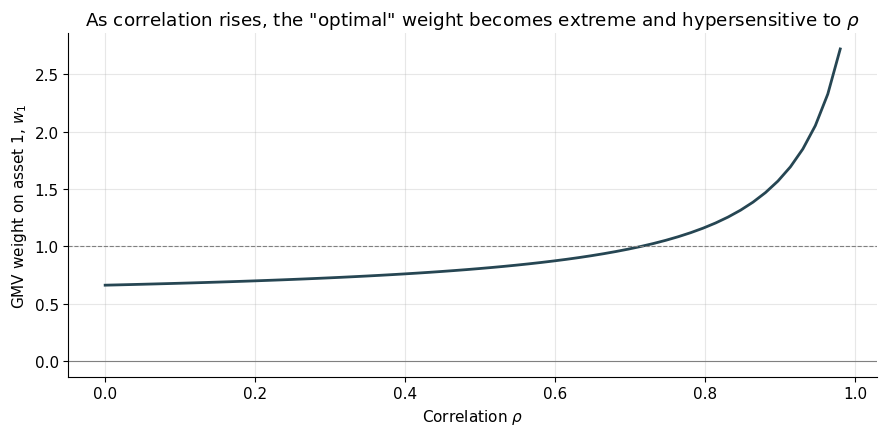

In [4]:
sigma1, sigma2 = 0.20, 0.28   # fix two volatilities, sweep correlation
rhos = np.linspace(0.0, 0.98, 60)
w1 = (sigma2**2 - rhos*sigma1*sigma2) / (sigma1**2 + sigma2**2 - 2*rhos*sigma1*sigma2)

fig, ax = plt.subplots()
ax.plot(rhos, w1, color='#264653', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axhline(1, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel(r'Correlation $\rho$')
ax.set_ylabel(r'GMV weight on asset 1, $w_1$')
ax.set_title(r'As correlation rises, the "optimal" weight becomes extreme and hypersensitive to $\rho$')
plt.tight_layout()
plt.show()

### 4.3 The bootstrap experiment: how unstable are the weights, really?

We repeatedly draw a realistic-sized sample (one trading year, $T=252$ days) from the **known true** distribution, compute the sample $\hat\mu,\hat\Sigma$, solve for the "optimal" portfolio from *that sample alone* (exactly as a practitioner would, blind to the truth), and record the weights. Two hundred repetitions later, we can look at the actual distribution of "optimal" weights the same procedure would have produced, purely from sampling variation.

In [5]:
def simulate_returns(mu_ann, Sigma_ann, T, seed):
    """Simulate T i.i.d. daily returns consistent with the given annualized mu, Sigma."""
    local_rng = np.random.default_rng(seed)
    return local_rng.multivariate_normal(mu_ann/252, Sigma_ann/252, size=T)

def bootstrap_weights(weight_fn, needs_mu, T, n_boot, seed):
    """Repeatedly resample T days, refit, and record the resulting weights."""
    local_rng = np.random.default_rng(seed)
    all_weights = np.zeros((n_boot, N))
    for b in range(n_boot):
        X = simulate_returns(TRUE_ANN_MU, TRUE_SIGMA, T, seed=local_rng.integers(1, 10**9))
        mu_hat, Sigma_hat = X.mean(axis=0)*252, np.cov(X, rowvar=False)*252
        all_weights[b] = weight_fn(mu_hat, Sigma_hat) if needs_mu else weight_fn(Sigma_hat)
    return all_weights

gmv_boot = bootstrap_weights(lambda Sigma: gmv_weights(Sigma), needs_mu=False, T=252, n_boot=200, seed=1)
tan_boot = bootstrap_weights(lambda mu, Sigma: tangency_weights(mu, Sigma, rf=0.02), needs_mu=True, T=252, n_boot=200, seed=1)

print("GMV weights across 200 resamples -- mean and std per asset:")
print(pd.DataFrame({'mean': gmv_boot.mean(axis=0), 'std': gmv_boot.std(axis=0)}, index=TICKERS).round(3))

GMV weights across 200 resamples -- mean and std per asset:
       mean    std
GALP  0.010  0.017
EDP   0.022  0.017
JMT   0.030  0.019
BCP   0.005  0.015
NOS  -0.000  0.015
SEM  -0.004  0.013
SPY   0.112  0.022
IEF   0.825  0.021


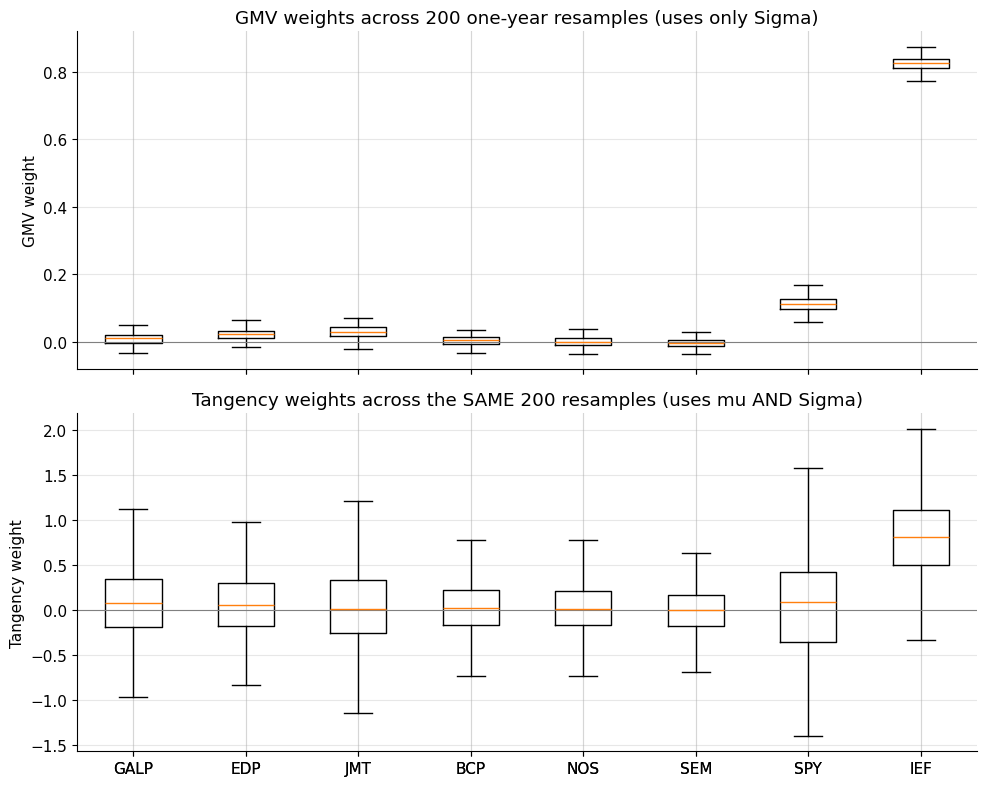

Average weight std. dev. across assets -- GMV: 0.017   Tangency: 4.113


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].boxplot(gmv_boot, tick_labels=TICKERS, showfliers=False)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_ylabel('GMV weight')
axes[0].set_title('GMV weights across 200 one-year resamples (uses only Sigma)')

axes[1].boxplot(tan_boot, tick_labels=TICKERS, showfliers=False)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_ylabel('Tangency weight')
axes[1].set_title('Tangency weights across the SAME 200 resamples (uses mu AND Sigma)')

plt.tight_layout()
plt.show()

print(f"Average weight std. dev. across assets -- GMV: {gmv_boot.std(axis=0).mean():.3f}   "
      f"Tangency: {tan_boot.std(axis=0).mean():.3f}")

Both portfolios swing around from sample to sample, but the tangency portfolio — the one that has to estimate $\mu$ — is dramatically more erratic than the GMV portfolio, which needs only $\Sigma$. This is the direct, empirical version of Section 3.2's standard-error argument: since $\mu$ is so much harder to pin down than $\Sigma$, any portfolio construction method that depends heavily on $\hat\mu$ inherits that imprecision almost one-for-one.

### 4.4 Does "optimal" actually win out-of-sample?

The real test is not how the portfolio looks in-sample, but how it performs *afterward*, on data it never saw. We roll a 252-day estimation window forward through a longer simulated (or real, if available) history, re-fit GMV weights at each step, hold them for the next 21 trading days (one month), then roll forward — and compare the resulting realized performance to the trivial equal-weight ("1/N") portfolio, which requires no estimation at all.

In [7]:
def load_universe_panel(tickers, start='2019-01-01', end='2025-06-30'):
    import io, contextlib, logging
    try:
        import yfinance as yf
        logging.getLogger('yfinance').setLevel(logging.CRITICAL)
        yf_tickers = [t + '.LS' if t in ['GALP','EDP','JMT','BCP','NOS','SEM'] else t for t in tickers]
        _buf = io.StringIO()
        with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
            raw = yf.download(yf_tickers, start=start, end=end, progress=False,
                               auto_adjust=True, group_by='ticker')
        rets = {}
        for tk, yf_tk in zip(tickers, yf_tickers):
            px = raw[yf_tk]['Close'].dropna()
            r = px.pct_change().dropna()
            if len(r) < 500:
                raise RuntimeError(f"insufficient rows for {yf_tk}")
            rets[tk] = r
        panel = pd.DataFrame(rets).dropna()
        print(f"Loaded real daily returns via yfinance: {len(panel)} trading days.")
        return panel
    except Exception as e:
        print(f"yfinance path unavailable ({type(e).__name__}). Falling back to the simulated universe "
              f"defined in Section 4.1 (this is the SAME data-generating process used throughout Module 2).")
        X = simulate_returns(TRUE_ANN_MU, TRUE_SIGMA, T=1500, seed=99)
        idx = pd.bdate_range('2019-01-02', periods=1500)
        return pd.DataFrame(X, columns=tickers, index=idx)

panel = load_universe_panel(TICKERS)
panel.tail()

yfinance path unavailable (RuntimeError). Falling back to the simulated universe defined in Section 4.1 (this is the SAME data-generating process used throughout Module 2).


,GALP,EDP,JMT,BCP,NOS,SEM,SPY,IEF
2024-09-25,0.003622,-0.015604,0.013526,0.026557,-0.011008,0.003913,-0.007244,-0.002656
2024-09-26,0.005239,-0.001892,-0.020814,0.001183,-0.004015,-0.016688,0.004283,0.000508
2024-09-27,0.004030,0.020910,-0.016427,0.020156,-0.001312,0.020764,-0.002620,-0.005752
2024-09-30,-0.003713,-0.005546,-0.009176,-0.008213,-0.011460,0.032279,0.006927,0.003449
2024-10-01,-0.018130,0.007075,0.001849,-0.008665,-0.004129,-0.033083,0.000073,0.000175


In [8]:
def rolling_backtest(panel, est_window=252, rebal_every=21):
    dates = panel.index
    gmv_ret, ew_ret, gmv_weights_over_time = [], [], []
    t = est_window
    w_gmv = np.ones(N) / N
    while t + rebal_every <= len(panel):
        est = panel.iloc[t-est_window:t].values
        Sigma_hat = np.cov(est, rowvar=False)
        try:
            w_gmv = gmv_weights(Sigma_hat)
        except np.linalg.LinAlgError:
            pass  # keep previous weights if Sigma_hat is singular
        gmv_weights_over_time.append(w_gmv.copy())

        hold = panel.iloc[t:t+rebal_every].values
        gmv_ret.extend(hold @ w_gmv)
        ew_ret.extend(hold @ (np.ones(N)/N))
        t += rebal_every

    idx = dates[est_window:est_window+len(gmv_ret)]
    return (pd.Series(gmv_ret, index=idx), pd.Series(ew_ret, index=idx),
            pd.DataFrame(gmv_weights_over_time, columns=TICKERS))

gmv_oos, ew_oos, weights_over_time = rolling_backtest(panel)

def perf_stats(r):
    ann_ret = r.mean()*252
    ann_vol = r.std()*np.sqrt(252)
    sharpe = ann_ret/ann_vol
    return ann_ret, ann_vol, sharpe

for name, r in [('Rolling GMV', gmv_oos), ('Equal-weight (1/N)', ew_oos)]:
    ar, av, sh = perf_stats(r)
    print(f"{name:20s}  ann. return {ar:6.2%}   ann. vol {av:6.2%}   Sharpe {sh:5.2f}")

Rolling GMV           ann. return  2.92%   ann. vol  5.52%   Sharpe  0.53
Equal-weight (1/N)    ann. return  8.93%   ann. vol 15.37%   Sharpe  0.58


## 5. Worked example

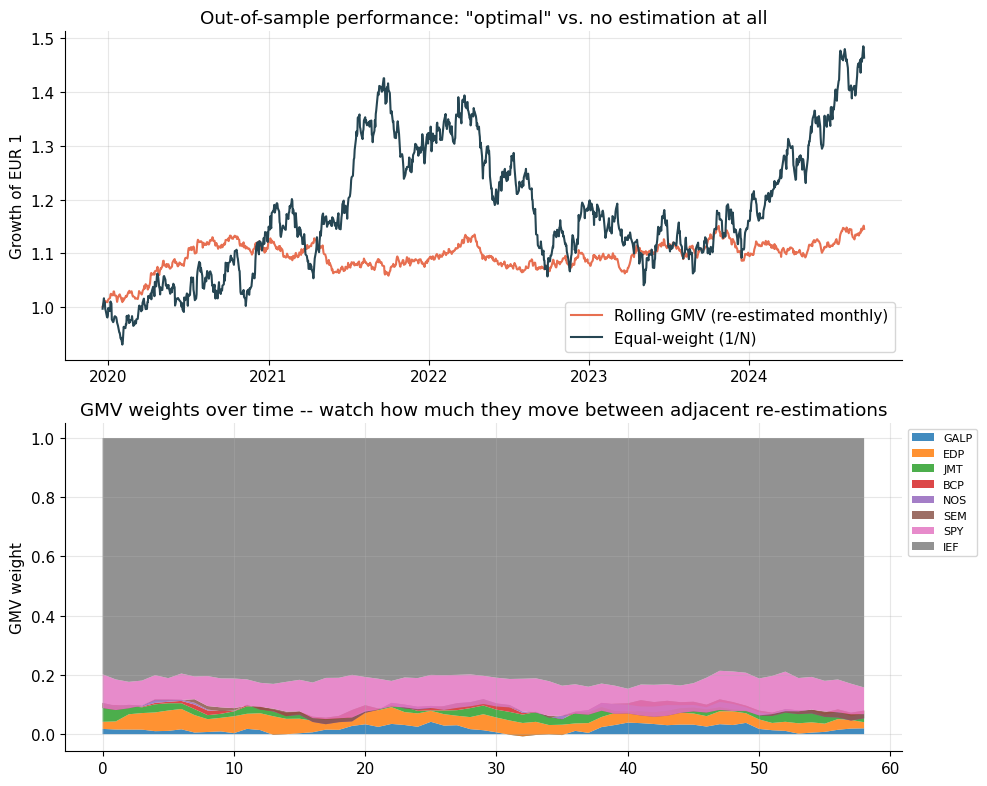

Average month-to-month GMV turnover (sum of |weight changes|): 0.048


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot((1+gmv_oos).cumprod(), label='Rolling GMV (re-estimated monthly)', color='#e76f51')
axes[0].plot((1+ew_oos).cumprod(), label='Equal-weight (1/N)', color='#264653')
axes[0].set_ylabel('Growth of EUR 1')
axes[0].set_title('Out-of-sample performance: "optimal" vs. no estimation at all')
axes[0].legend()

axes[1].stackplot(weights_over_time.index, weights_over_time.values.T, labels=TICKERS, alpha=0.85)
axes[1].set_ylabel('GMV weight')
axes[1].set_title('GMV weights over time -- watch how much they move between adjacent re-estimations')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=8)

plt.tight_layout()
plt.show()

turnover = weights_over_time.diff().abs().sum(axis=1).mean()
print(f"Average month-to-month GMV turnover (sum of |weight changes|): {turnover:.3f}")

### Interpreting the result

Two things typically stand out (report what your own run actually shows — that is the point of running it yourself, not taking a canned conclusion on faith). First, the weight stack plot rarely looks calm: bands widen and narrow noticeably from one month to the next, even though nothing about the underlying assets changed structurally — this is estimation noise being re-injected every single re-estimation. Second, the *performance* gap between rolling GMV and simple 1/N is often much smaller than the in-sample optimization would have led you to expect, and is not reliably in GMV's favor. This mirrors a well-known empirical finding: DeMiguel, Garlappi & Uppal (2009) compared naive 1/N diversification against a wide range of "optimal" portfolio construction methods across many real datasets, and found 1/N was strikingly hard to beat out-of-sample, precisely because of the estimation error this notebook has been dissecting.

## 6. Limitations and pitfalls

- **Mean-variance optimization only cares about the first two moments.** It is blind to skewness and tail risk — an asset with a modest "normal" volatility but occasional catastrophic drawdowns looks no more dangerous, to this framework, than one with genuinely symmetric risk. Module 4's copulas and Module 6's tail-risk tools address this gap.
- **We assumed $\mu,\Sigma$ are constant over time.** Real markets go through regimes — calm and volatile, trending and mean-reverting — that a single static estimate cannot capture (Notebook 16 introduces regime-switching models directly).
- **Rebalancing into unstable weights has real costs.** Every time the "optimal" portfolio swings, implementing that swing means trading, and trading costs money (Notebook 28). A method that looks marginally better on paper but churns constantly can easily lose to a stable, cheaper alternative net of costs.
- **The no-short-selling constraint, which we did not impose here, is not a principled fix** — it happens to reduce instability in practice mostly by mechanically capping how extreme weights can get, not by addressing the underlying estimation-error problem. Exercise 3 asks you to check this yourself.

## 7. Exercises

**1. How much data would you need? (warm-up)**
Using $SE(\hat\mu)=\sigma/\sqrt T$, compute the standard error of the mean for assets with annual volatility 15%, 25%, and 35%, at sample sizes $T=$ 2, 5, 10, and 20 years of *monthly* data. How many years would it take to get the standard error for the 25%-vol asset below 1%? Is that a realistic amount of stationary history to expect from any real market?

**2. Correlation and instability, systematically.**
Re-run the bootstrap experiment from Section 4.3, but with the off-diagonal PSI-20 correlation in `corr` changed from 0.45 to 0.10 (low-correlation universe) and separately to 0.85 (high-correlation universe), leaving everything else fixed. Compare the resulting `gmv_boot.std(axis=0).mean()` across the three cases. Does the instability scale the way Section 3.3's two-asset formula predicts?

**3. Does a long-only constraint actually help?**
Re-implement `gmv_weights` as a constrained numerical optimization (`scipy.optimize.minimize`, method `'SLSQP'`, with bounds $w_i \in [0,1]$ and the constraint $\sum w_i = 1$) instead of the closed form. Repeat the Section 4.3 bootstrap using this constrained version and compare the resulting weight standard deviations to the unconstrained case. Does forbidding short positions meaningfully reduce instability here? Why might a practitioner still be cautious about calling this a real fix, rather than a band-aid, for the underlying estimation-error problem?